In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
scheme = pd.read_csv("../data/processed/scheme_performance_clean.csv")
trans = pd.read_csv("../data/processed/investor_transactions_clean.csv")
holding = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

nav["date"] = pd.to_datetime(nav["date"])
trans["transaction_date"] = pd.to_datetime(trans["transaction_date"])

print(nav.shape)
print(scheme.shape)
print(trans.shape)
print(holding.shape)

(46000, 3)
(40, 19)
(32778, 13)
(322, 8)


In [3]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

var_report = nav.groupby(
    "amfi_code"
)["daily_return"].apply(
    lambda x: np.percentile(
        x.dropna(),
        5
    )
).reset_index()

var_report.columns = [
    "amfi_code",
    "VaR_95"
]

cvar = nav.groupby(
    "amfi_code"
)["daily_return"].apply(
    lambda x: x[
        x <= np.percentile(
            x.dropna(),
            5
        )
    ].mean()
).reset_index()

cvar.columns = [
    "amfi_code",
    "CVaR"
]

var_report = var_report.merge(
    cvar,
    on="amfi_code"
)

var_report = var_report.merge(
    scheme[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code"
)

var_report.head()

,amfi_code,VaR_95,CVaR,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [5]:
var_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

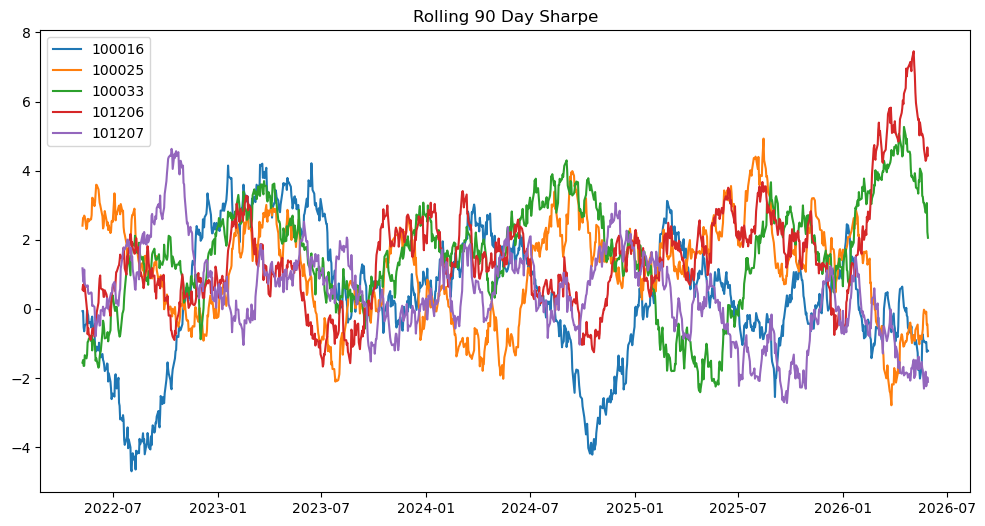

In [6]:
top5 = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:5]
    )
]

plt.figure(figsize=(12,6))

for code in top5["amfi_code"].unique():

    temp = top5[
        top5["amfi_code"] == code
    ].copy()

    rolling = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling,
        label=str(code)
    )

plt.legend()

plt.title(
    "Rolling 90 Day Sharpe"
)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [7]:
trans["cohort"] = (
    trans
    ["transaction_date"]
    .dt
    .year
)

cohort = trans.groupby(
    "cohort"
).agg(
    avg_sip_amount=(
        "amount_inr",
        "mean"
    ),
    total_invested=(
        "amount_inr",
        "sum"
    )
)

cohort

,avg_sip_amount,total_invested
cohort,,
2024,107739.476605,2500633252
2025,106704.345527,1020947178


In [8]:
pref = trans.groupby(
    [
        "cohort",
        "amfi_code"
    ]
).size().reset_index(
    name="count"
)

pref = pref.sort_values(
    [
        "cohort",
        "count"
    ],
    ascending=False
)

pref.head()

,cohort,amfi_code,count
59,2025,119551,271
69,2025,120842,265
75,2025,148568,263
73,2025,125498,260
57,2025,119095,259


In [13]:
sip = trans[
    trans[
        "transaction_type"
    ] == "SIP"
].copy()

sip = sip.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

sip["gap"] = sip.groupby(
    "investor_id"
)[
    "transaction_date"
].diff().dt.days

risk = sip.groupby(
    "investor_id"
).agg(
    avg_gap=(
        "gap",
        "mean"
    ),
    sip_count=(
        "gap",
        "count"
    )
)

risk = risk[
    risk[
        "sip_count"
    ] >= 6
]

risk["status"] = np.where(
    risk[
        "avg_gap"
    ] > 35,
    "At Risk",
    "Healthy"
)

risk.head()

,avg_gap,sip_count,status
investor_id,,,


In [12]:
def recommend(
    risk_level
):

    return scheme[
        scheme[
            "risk_grade"
        ] == risk_level
    ].sort_values(
        "sharpe_ratio",
        ascending=False
    )[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio"
        ]
    ].head(3)

recommend(
    "High"
)

,scheme_name,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
38,DSP Midcap Fund - Regular - Growth,High,0.90


In [14]:
holding["weight_sq"] = (
    holding[
        "weight_pct"
    ] / 100
) ** 2

hhi = holding.groupby(
    "amfi_code"
)[
    "weight_sq"
].sum().reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi = hhi.merge(
    scheme[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code"
)

hhi.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


## Advanced Insights

1. Small cap funds show the highest Value at Risk.

2. CVaR indicates downside risk is concentrated in a few schemes.

3. Investors from recent cohorts invest higher average SIP amounts.

4. SIP continuity analysis identifies investors with irregular contributions.

5. Highly concentrated portfolios have larger HHI values.